# Bank Fraud Detection — Data Preparation & Exploratory Analysis

## Phase 1

This notebook focuses on understanding, validating, exploring and preparing the credit card transaction dataset before developing machine learning and deep learning models.

The overall project will benchmark four levels of fraud detection approaches:

- **Tier 1 — Machine Learning**
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM

- **Tier 2 — Deep Learning for Tabular Data**
  - Multilayer Perceptron (MLP)
  - Autoencoder

- **Tier 3 — Temporal Deep Learning**
  - LSTM
  - GRU
  - 1D CNN

- **Tier 4 — Advanced Deep Learning**
  - Transformer
  - Graph Neural Network (GNN)

The primary objective is to compare these approaches using evaluation metrics that are appropriate for highly imbalanced fraud detection problems.

## 1. Business Problem

Financial fraud detection is a highly imbalanced binary classification problem.

In a real banking environment, fraudulent transactions represent only a small proportion of total transactions. Therefore, a model can achieve very high accuracy while failing to detect a significant proportion of fraudulent activity.

The objective of this project is to develop and benchmark multiple machine learning and deep learning approaches for identifying potentially fraudulent transactions.

The analysis will focus on:

- Fraud detection performance
- Precision and recall trade-offs
- Precision-Recall AUC (PR-AUC)
- False positives and false negatives
- Classification threshold optimisation
- Model complexity
- Training efficiency
- Business implications of model errors

## 2. Project Hypothesis

The project investigates whether increasingly sophisticated modelling approaches provide meaningful improvements over traditional machine learning methods for fraud detection.

The main hypotheses are:

1. Gradient boosting models will provide strong performance on tabular transaction data.
2. Deep learning models may capture additional non-linear relationships between transaction features.
3. Temporal models may benefit from transaction sequences and behavioural patterns.
4. Transformer-based architectures may capture long-range dependencies in transaction sequences.
5. Graph Neural Networks may provide additional value when relationships between customers, accounts, devices and merchants are explicitly represented as a graph.

These hypotheses will be evaluated empirically rather than assumed to be true.

In [138]:
# 2.1 Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [139]:
# 2.2 Pandas Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


#2.3 Seaborn Configuration

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [140]:
#2.4 Print Library Versions
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.5.3
Pandas version: 3.0.5


## 3. Project Paths

The project uses relative paths so that the notebook remains portable across different machines and environments.

Raw data will be read from the `data/raw` directory and processed datasets will later be stored in `data/processed`.

In [141]:
PROJECT_ROOT = Path("..")

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "creditcard.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT.resolve())
print("Raw data path:", RAW_DATA_PATH.resolve())
print("Processed data path:", PROCESSED_DATA_PATH.resolve())

Project root: /home/anderjcruz/projects/Bank-Fraud-Detection
Raw data path: /home/anderjcruz/projects/Bank-Fraud-Detection/data/raw
Processed data path: /home/anderjcruz/projects/Bank-Fraud-Detection/data/processed


In [142]:
#3.1 Validate the file

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {RAW_DATA_PATH.resolve()}"
    )

print(f"Dataset found: {RAW_DATA_PATH.resolve()}")

Dataset found: /home/anderjcruz/projects/Bank-Fraud-Detection/data/raw/creditcard.csv


## 4. Dataset Loading

The dataset used in this project is the Credit Card Fraud Detection dataset provided by the Machine Learning Group of ULB.

The dataset contains anonymised credit card transactions and a binary target variable indicating whether a transaction is fraudulent.

The original dataset contains approximately 285,000 transactions, with fraud representing a very small proportion of all observations.

In [143]:
df = pd.read_csv(RAW_DATA_PATH)

In [144]:
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (284807, 31)


In [145]:
# 4.1 Display the first few rows of the dataset

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [146]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [147]:
#4.2 Display the shape of the dataset

rows, columns = df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns:,}")

Rows: 284,807
Columns: 31


In [148]:
# 4.3 Display the column names of the dataset
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']



## 5. Dataset Overview

The first step after loading the data is to understand its basic structure.

We will inspect:

- Number of observations
- Number of features
- Column names
- Data types
- Summary statistics

This provides the foundation for the subsequent data quality and exploratory analysis.

In [149]:
# 5. Display the data types of each column in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [150]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### 5.1 Identify the target

In [151]:
TARGET = "Class"

print(f"Target variable: {TARGET}")
print(f"Target data type: {df[TARGET].dtype}")
print(f"Unique target values: {df[TARGET].unique()}")

Target variable: Class
Target data type: int64
Unique target values: [0 1]


### 5.2 Confirm the problem type

In [152]:
unique_target_values = df[TARGET].nunique()

print(f"Number of unique target values: {unique_target_values}")

Number of unique target values: 2


In [153]:
class_counts = df[TARGET].value_counts().sort_index()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [154]:
class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(df) * 100
})

class_distribution

,count,percentage
Class,,
0,284315,99.827251
1,492,0.172749


## 6. Data Quality Assessment

Before performing statistical analysis or model training, the dataset must be checked for common data quality issues.

The following checks will be performed:

- Missing values
- Duplicate records
- Infinite values
- Data types
- Constant or near-constant variables

In [155]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [156]:
print(f"Total missing values: {df.isnull().sum().sum():,}")

Total missing values: 0


In [157]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 1,081


In [158]:
infinite_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

print(f"Infinite values: {infinite_count:,}")

Infinite values: 0


## 6.1 Duplicate Record Investigation

The dataset contains duplicate rows. Before removing them, we need to determine whether duplicated observations are associated with legitimate or fraudulent transactions.

Removing duplicates without investigation could alter the class distribution and potentially remove meaningful observations.

Therefore, duplicates will be analysed before any cleaning decision is made.

In [159]:
# Number of duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 1,081


In [160]:
duplicate_mask = df.duplicated(keep=False)

duplicate_data = df.loc[duplicate_mask]

print(f"Rows belonging to duplicated groups: {len(duplicate_data):,}")

Rows belonging to duplicated groups: 1,854


In [161]:
duplicate_class_distribution = (
    duplicate_data[TARGET]
    .value_counts()
    .sort_index()
)

duplicate_class_distribution

Class
0    1822
1      32
Name: count, dtype: int64

In [162]:
duplicate_class_percentage = (
    duplicate_data[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

duplicate_class_percentage

Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64

## 7. Fraud Distribution

Fraud detection is typically characterised by severe class imbalance.

A small proportion of transactions are fraudulent compared with legitimate transactions.

Understanding the class distribution is critical because conventional accuracy can become misleading in highly imbalanced classification problems.

In [163]:
class_counts = df[TARGET].value_counts().sort_index()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [164]:
class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(df) * 100
})

class_distribution

,count,percentage
Class,,
0,284315,99.827251
1,492,0.172749


In [165]:
df["Amount_log"] = np.log1p(df["Amount"])

In [166]:
df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [167]:
print(f"Original Amount skewness: {df['Amount'].skew():.4f}")
print(f"Log-transformed Amount skewness: {df['Amount_log'].skew():.4f}")

Original Amount skewness: 16.9777
Log-transformed Amount skewness: 0.1627


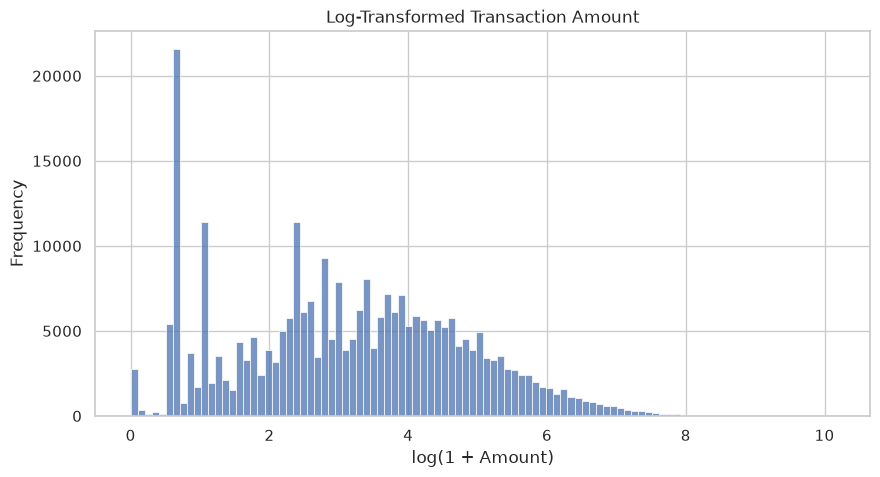

In [168]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount_log",
    bins=100
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")

plt.show()

## 8. Transaction Amount Distribution

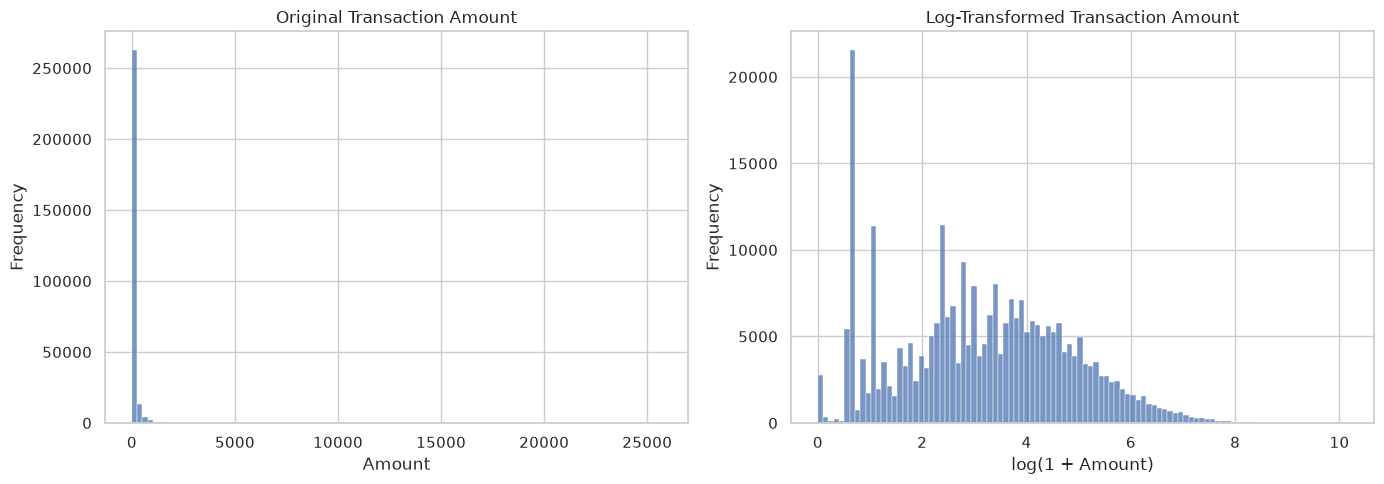

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100,
    ax=axes[0]
)

axes[0].set_title("Original Transaction Amount")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency")

sns.histplot(
    data=df,
    x="Amount_log",
    bins=100,
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Transaction Amount")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 8.1 Transaction Amount by Class
The transaction amount distribution differs between legitimate and fraudulent transactions, particularly across the distribution's lower and upper ranges.

In [170]:
amount_by_class = (
    df.groupby(TARGET)["Amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

amount_by_class

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


In [171]:
amount_quantiles = (
    df.groupby(TARGET)["Amount"]
    .quantile([0.25, 0.50, 0.75, 0.95, 0.99])
    .unstack()
)

amount_quantiles

,0.25,0.50,0.75,0.95,0.99
Class,,,,,
0,5.65,22.00,77.05,364.409,1016.9664
1,1.00,9.25,105.89,640.905,1357.4279


### 8.2 Transaction Amount by Class — Log Scale
Transaction amount exhibits different distributional characteristics between legitimate and fraudulent transactions, suggesting that it may contain predictive information.

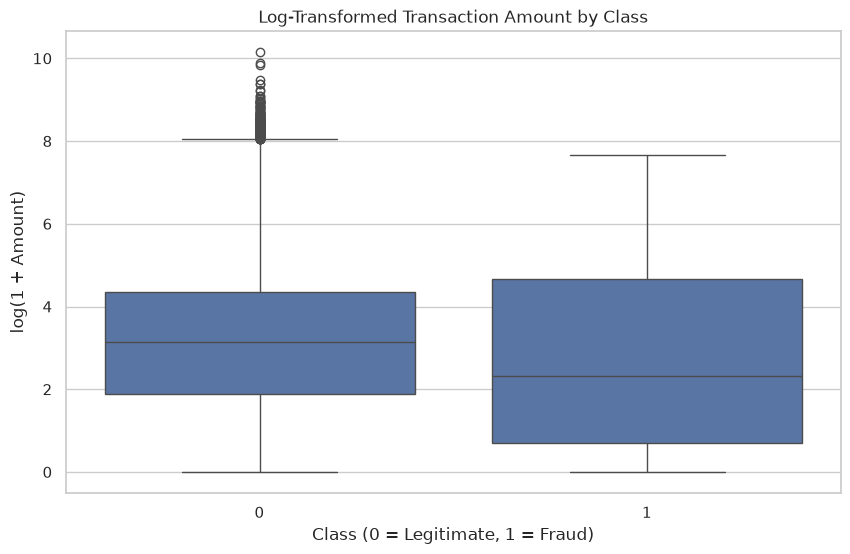

In [172]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET,
    y="Amount_log"
)

plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("log(1 + Amount)")

plt.show()

### EDA Finding

The transaction amount distributions differ between legitimate and fraudulent transactions.

Although fraudulent transactions have a higher mean transaction amount, their median is lower than that of legitimate transactions. This indicates that the distributions are highly skewed and that a small number of higher-value transactions influence the mean.

The log transformation substantially reduces the skewness of the `Amount` variable, making the distribution easier to analyse and potentially more suitable for scale-sensitive models.

The `Amount` variable will therefore be retained as a candidate predictive feature. Its actual contribution to fraud detection will be evaluated during the modelling phases.

## 9. Time Analysis

The `Time` variable represents the elapsed time, in seconds, since the first transaction recorded in the dataset.

This variable provides temporal information that may be relevant for sequential modelling in later phases.

In [180]:
time_stats = df["Time"].describe()

time_stats

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [181]:
df["Time_hours"] = df["Time"] / 3600

In [182]:
print(f"Time range: {df['Time_hours'].min():.2f} to {df['Time_hours'].max():.2f} hours")

Time range: 0.00 to 48.00 hours


In [183]:
is_time_sorted = df["Time"].is_monotonic_increasing

print(f"Transactions are chronologically ordered: {is_time_sorted}")

Transactions are chronologically ordered: True


In [184]:
time_unique = df["Time"].nunique()
time_total = len(df)

print(f"Total transactions: {time_total:,}")
print(f"Unique Time values: {time_unique:,}")
print(f"Transactions sharing a Time value: {time_total - time_unique:,}")

Total transactions: 284,807
Unique Time values: 124,592
Transactions sharing a Time value: 160,215


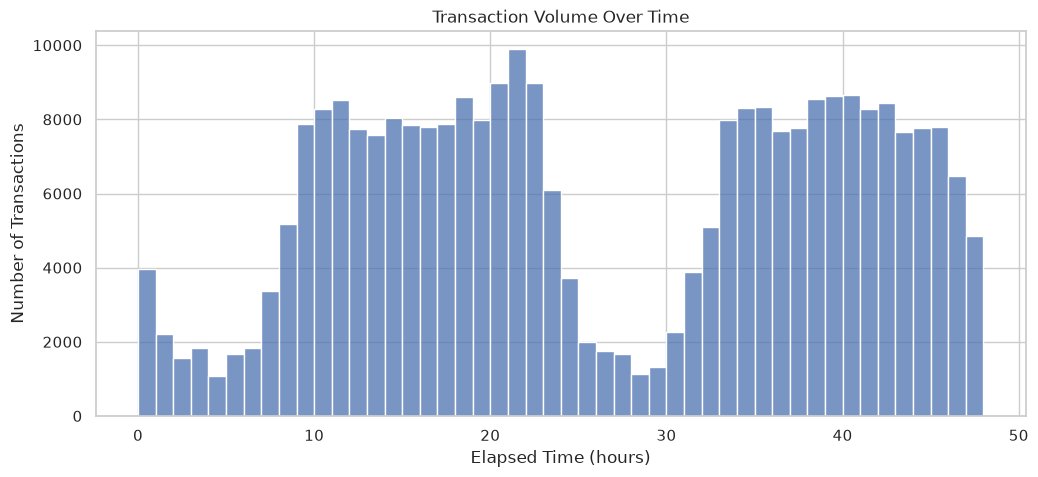

In [185]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time_hours",
    bins=48
)

plt.title("Transaction Volume Over Time")
plt.xlabel("Elapsed Time (hours)")
plt.ylabel("Number of Transactions")

plt.show()

In [187]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [188]:
df["Time"].nunique()

124592

In [189]:
df["Time"].is_monotonic_increasing

True

In [186]:
time_by_class = (
    df.groupby(TARGET)["Time_hours"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

time_by_class

,count,mean,median,min,max
Class,,,,,
0,284315,26.343945,23.530833,0.000000,47.997778
1,492,22.429669,20.991250,0.112778,47.318889


### 9.1 Fraud Rate Over Time

In [190]:
time_bins = pd.cut(
    df["Time_hours"],
    bins=48
)

df["Time_bin"] = time_bins

In [191]:
fraud_rate_over_time = (
    df.groupby("Time_bin", observed=True)[TARGET]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

fraud_rate_over_time.head()

,transactions,fraud_count,fraud_rate
Time_bin,,,
"(-0.048, 1.0]",3963,2,0.000505
"(1.0, 2.0]",2217,2,0.000902
"(2.0, 3.0]",1576,21,0.013325
"(3.0, 4.0]",1821,13,0.007139
"(4.0, 5.0]",1082,6,0.005545


In [192]:
fraud_rate_over_time["fraud_rate_pct"] = (
    fraud_rate_over_time["fraud_rate"] * 100
)

In [193]:
fraud_rate_over_time.head()

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_bin,,,,
"(-0.048, 1.0]",3963,2,0.000505,0.050467
"(1.0, 2.0]",2217,2,0.000902,0.090212
"(2.0, 3.0]",1576,21,0.013325,1.332487
"(3.0, 4.0]",1821,13,0.007139,0.713893
"(4.0, 5.0]",1082,6,0.005545,0.554529


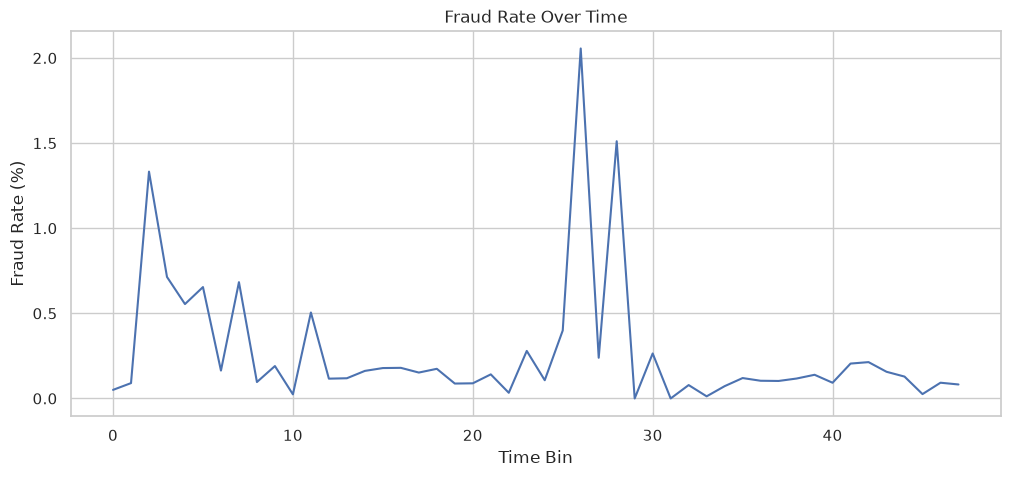

In [194]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(fraud_rate_over_time)),
    fraud_rate_over_time["fraud_rate_pct"]
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Time Bin")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [195]:
top_fraud_rate_bins = (
    fraud_rate_over_time
    .sort_values("fraud_rate", ascending=False)
    .head(10)
)

top_fraud_rate_bins

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_bin,,,,
"(25.999, 26.999]",1751,36,0.020560,2.055968
"(27.999, 28.999]",1125,17,0.015111,1.511111
"(2.0, 3.0]",1576,21,0.013325,1.332487
"(3.0, 4.0]",1821,13,0.007139,0.713893
"(7.0, 8.0]",3366,23,0.006833,0.683304
"(5.0, 6.0]",1681,11,0.006544,0.654372
"(4.0, 5.0]",1082,6,0.005545,0.554529
"(10.999, 11.999]",8514,43,0.005051,0.505051
"(24.999, 25.999]",2003,8,0.003994,0.399401


### EDA Finding

The observed fraud rate varies considerably across the 48-hour observation period.

The highest observed fraud rate occurs between approximately 26 and 27 hours, reaching 2.06%, compared with an overall fraud rate of approximately 0.17%.

However, the time interval with the highest fraud rate is not necessarily the interval with the highest number of fraudulent transactions. For example, the 11–12 hour interval contains 43 fraudulent transactions but has a lower fraud rate because it also contains substantially more transactions.

This demonstrates the importance of considering both fraud counts and transaction volumes when analysing temporal fraud patterns.

In [199]:
top_fraud_count_bins = (
    fraud_rate_over_time
    .sort_values("fraud_count", ascending=False)
    .head(10)
)

In [200]:
top_fraud_count_bins

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_bin,,,,
"(10.999, 11.999]",8514,43,0.005051,0.505051
"(25.999, 26.999]",1751,36,0.020560,2.055968
"(7.0, 8.0]",3366,23,0.006833,0.683304
"(2.0, 3.0]",1576,21,0.013325,1.332487
"(41.998, 42.998]",8431,18,0.002135,0.213498
"(27.999, 28.999]",1125,17,0.015111,1.511111
"(22.999, 23.999]",6087,17,0.002793,0.279284
"(40.998, 41.998]",8293,17,0.002050,0.204992
"(17.999, 18.999]",8608,15,0.001743,0.174257


In [202]:
df["Time_hour"] = np.floor(df["Time_hours"]).astype(int)

In [203]:
fraud_by_hour = (
    df.groupby("Time_hour")[TARGET]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

In [204]:
fraud_by_hour["fraud_rate_pct"] = (
    fraud_by_hour["fraud_rate"] * 100
)

In [205]:
fraud_by_hour.head()

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_hour,,,,
0,3963,2,0.000505,0.050467
1,2217,2,0.000902,0.090212
2,1576,21,0.013325,1.332487
3,1821,13,0.007139,0.713893
4,1082,6,0.005545,0.554529


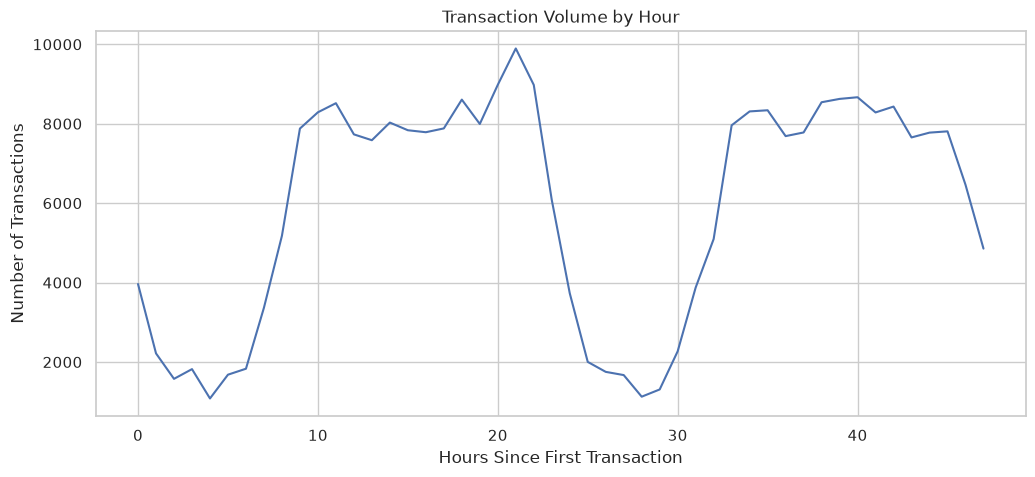

In [206]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["transactions"]
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hours Since First Transaction")
plt.ylabel("Number of Transactions")

plt.show()

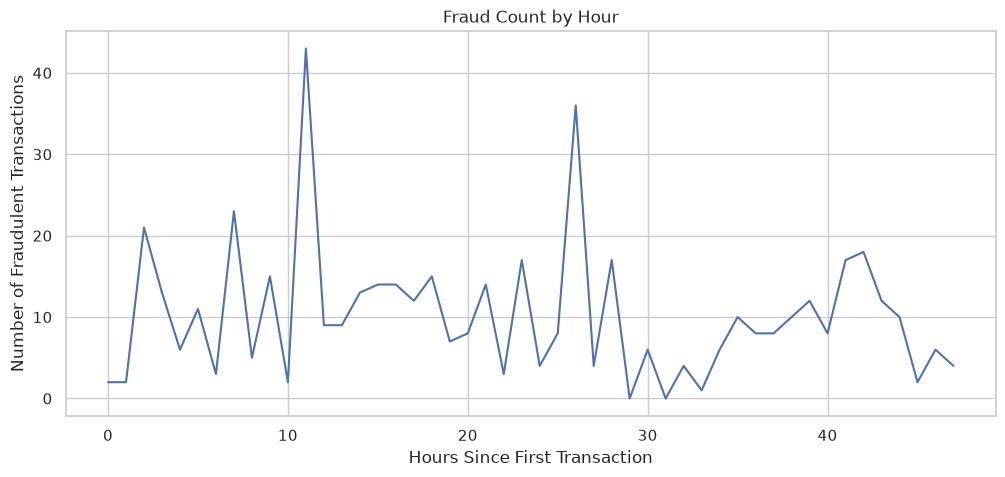

In [207]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["fraud_count"]
)

plt.title("Fraud Count by Hour")
plt.xlabel("Hours Since First Transaction")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

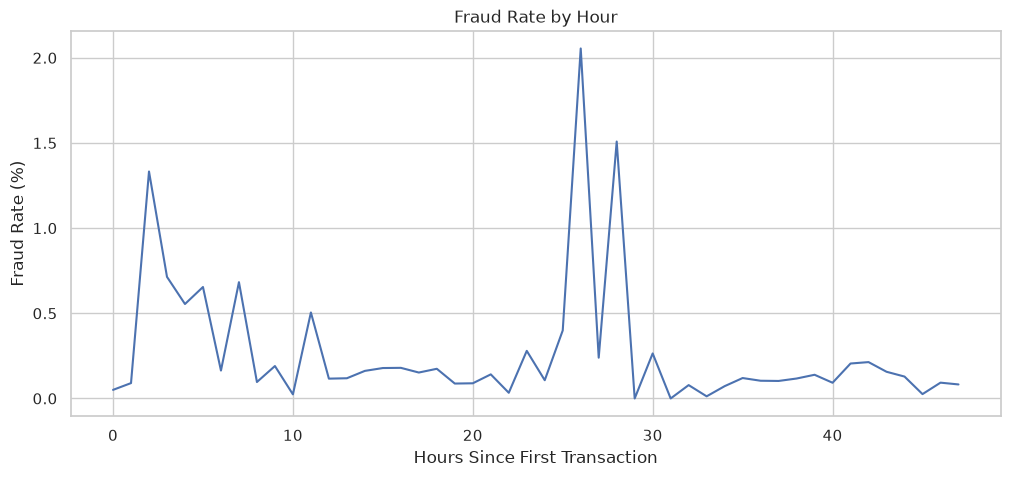

In [208]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["fraud_rate_pct"]
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hours Since First Transaction")
plt.ylabel("Fraud Rate (%)")

plt.show()

### EDA Finding

Transaction activity varies substantially across the approximately 48-hour observation period.

Fraud counts also vary across time, with several periods containing substantially more fraudulent transactions than others. When adjusted for transaction volume, the observed fraud rate also varies considerably between time intervals.

These findings indicate that temporal information may contain predictive signal for fraud detection. However, the dataset covers only approximately two days and does not provide explicit customer, account, merchant or device identifiers. Therefore, temporal patterns should be interpreted as dataset-specific observations rather than general behavioural rules.

The temporal structure will be investigated further during the sequential modelling phases.

## 10. Feature Distribution Analysis

In [209]:
PCA_FEATURES = [f"V{i}" for i in range(1, 29)]

print(f"Number of PCA features: {len(PCA_FEATURES)}")
print(PCA_FEATURES)

Number of PCA features: 28
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [210]:
feature_mean_by_class = df.groupby(TARGET)[PCA_FEATURES].mean().T

feature_mean_by_class

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


In [211]:
feature_median_by_class = df.groupby(TARGET)[PCA_FEATURES].median().T

feature_median_by_class

Class,0,1
V1,0.020023,-2.342497
V2,0.064070,2.717869
V3,0.182158,-5.075257
V4,-0.022405,4.177147
V5,-0.053457,-1.522962
V6,-0.273123,-1.424616
V7,0.041138,-3.034402
V8,0.022041,0.621508
V9,-0.049964,-2.208768
V10,-0.091872,-4.578825


In [212]:
feature_mean_difference = (
    feature_mean_by_class[1] -
    feature_mean_by_class[0]
).sort_values(key=np.abs, ascending=False)

feature_mean_difference

V3    -7.045452
V14   -6.983787
V17   -6.677371
V12   -6.270225
V10   -5.686707
V7    -5.578368
V1    -4.780206
V4     4.549889
V16   -4.147110
V11    3.806749
V2     3.630049
V5    -3.156678
V9    -2.585589
V18   -2.250195
V6    -1.400155
V21    0.714823
V19    0.681837
V8     0.571623
V20    0.372964
V27    0.170870
V13   -0.109523
V24   -0.105312
V15   -0.093090
V28    0.075798
V26    0.051738
V25    0.041521
V23   -0.040378
V22    0.014073
dtype: float64